In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("tanganke/eurosat")
print(dataset)

README.md:   0%|          | 0.00/5.01k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 73.5MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 9.13MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating jpeg_compression split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/2700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Get class names (forest, river, highway, etc.)
class_names = dataset["train"].features["label"].names
print(class_names)

Using device: cuda
['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']


In [ ]:
# For speed, we'll use a subset instead of all 21,600 images
# 300 images per class x 10 classes = 3000 training images total
def get_balanced_subset(hf_dataset, per_class=300, seed=42):
    random.seed(seed)
    indices_by_class = {}
    for idx, label in enumerate(hf_dataset["label"]):
        indices_by_class.setdefault(label, []).append(idx)

    selected = []
    for label, indices in indices_by_class.items():
        random.shuffle(indices)
        selected.extend(indices[:per_class])

    random.shuffle(selected)
    return hf_dataset.select(selected)

train_subset = get_balanced_subset(dataset["train"], per_class=300)
test_subset = get_balanced_subset(dataset["test"], per_class=60)

print("Train size:", len(train_subset))
print("Test size:", len(test_subset))

Train size: 3000
Test size: 600


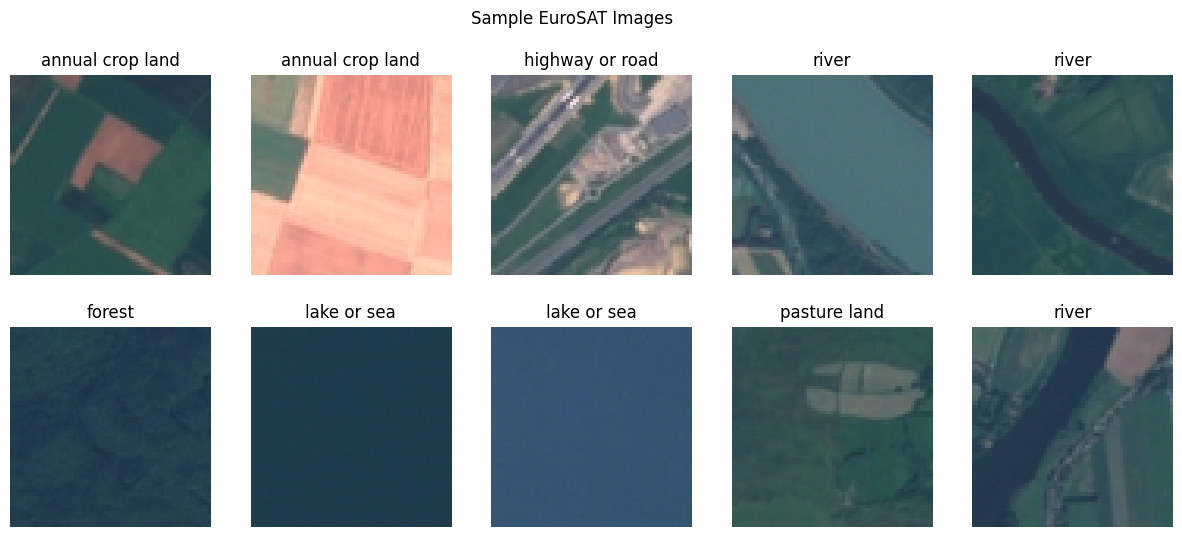

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = train_subset[i]["image"]
    label = train_subset[i]["label"]
    ax.imshow(img)
    ax.set_title(class_names[label])
    ax.axis("off")
plt.suptitle("Sample EuroSAT Images")
plt.show()

In [ ]:
# Basic transform - just resize and convert to tensor (numbers), no augmentation
basic_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Augmented transform - adds random flips/rotations during training
augmented_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class EuroSATDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        image = self.transform(image)
        return image, label

In [ ]:
BATCH_SIZE = 32

# Training data - two versions: without and with augmentation
train_dataset_noaug = EuroSATDataset(train_subset, basic_transform)
train_dataset_aug = EuroSATDataset(train_subset, augmented_transform)

# Test data - always uses basic_transform (we never augment test/eval data)
test_dataset = EuroSATDataset(test_subset, basic_transform)

train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready!")

DataLoaders ready!


In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- Evaluation phase ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        test_loss = val_loss / val_total
        test_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    return model, history

In [ ]:
print("=== Experiment 1: Scratch CNN, No Augmentation ===")
model_scratch_noaug = TinyVGG(num_classes=10)
model_scratch_noaug, history_scratch_noaug = train_model(
    model_scratch_noaug, train_loader_noaug, test_loader, epochs=10, lr=0.001
)

=== Experiment 1: Scratch CNN, No Augmentation ===
Epoch 1/10 | Train Loss: 1.7761, Train Acc: 0.3110 | Test Loss: 1.3650, Test Acc: 0.4933
Epoch 2/10 | Train Loss: 1.3524, Train Acc: 0.4927 | Test Loss: 1.2601, Test Acc: 0.4917
Epoch 3/10 | Train Loss: 1.2033, Train Acc: 0.5557 | Test Loss: 1.1129, Test Acc: 0.6017
Epoch 4/10 | Train Loss: 1.0391, Train Acc: 0.6210 | Test Loss: 0.9279, Test Acc: 0.6383
Epoch 5/10 | Train Loss: 0.9298, Train Acc: 0.6520 | Test Loss: 0.9071, Test Acc: 0.6650
Epoch 6/10 | Train Loss: 0.9087, Train Acc: 0.6773 | Test Loss: 0.8648, Test Acc: 0.6717
Epoch 7/10 | Train Loss: 0.7767, Train Acc: 0.7087 | Test Loss: 0.8455, Test Acc: 0.6717
Epoch 8/10 | Train Loss: 0.6977, Train Acc: 0.7493 | Test Loss: 0.7645, Test Acc: 0.7217
Epoch 9/10 | Train Loss: 0.6297, Train Acc: 0.7783 | Test Loss: 0.7377, Test Acc: 0.7283
Epoch 10/10 | Train Loss: 0.5461, Train Acc: 0.8087 | Test Loss: 0.7301, Test Acc: 0.7283


In [ ]:
print("=== Experiment 2: Scratch CNN, With Augmentation ===")
model_scratch_aug = TinyVGG(num_classes=10)
model_scratch_aug, history_scratch_aug = train_model(
    model_scratch_aug, train_loader_aug, test_loader, epochs=10, lr=0.001
)

=== Experiment 2: Scratch CNN, With Augmentation ===
Epoch 1/10 | Train Loss: 1.8865, Train Acc: 0.2713 | Test Loss: 1.4896, Test Acc: 0.4383
Epoch 2/10 | Train Loss: 1.4660, Train Acc: 0.4270 | Test Loss: 1.4488, Test Acc: 0.4517
Epoch 3/10 | Train Loss: 1.2909, Train Acc: 0.5043 | Test Loss: 1.2401, Test Acc: 0.5017
Epoch 4/10 | Train Loss: 1.2555, Train Acc: 0.5130 | Test Loss: 1.1156, Test Acc: 0.5333
Epoch 5/10 | Train Loss: 1.1414, Train Acc: 0.5640 | Test Loss: 1.0615, Test Acc: 0.5950
Epoch 6/10 | Train Loss: 1.0809, Train Acc: 0.6013 | Test Loss: 1.1636, Test Acc: 0.5133
Epoch 7/10 | Train Loss: 1.0774, Train Acc: 0.6110 | Test Loss: 0.9930, Test Acc: 0.6417
Epoch 8/10 | Train Loss: 0.9885, Train Acc: 0.6373 | Test Loss: 0.9413, Test Acc: 0.6400
Epoch 9/10 | Train Loss: 0.9365, Train Acc: 0.6580 | Test Loss: 0.8107, Test Acc: 0.6983
Epoch 10/10 | Train Loss: 0.8890, Train Acc: 0.6727 | Test Loss: 0.9613, Test Acc: 0.6517


In [ ]:
def build_pretrained_model(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all the pretrained layers so we don't destroy what they already learned
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final layer with one matching our 10 classes, and keep THIS trainable
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

In [ ]:
print("=== Experiment 3: Pretrained ResNet18, No Augmentation ===")
model_pretrained_noaug = build_pretrained_model(num_classes=10)
model_pretrained_noaug, history_pretrained_noaug = train_model(
    model_pretrained_noaug, train_loader_noaug, test_loader, epochs=5, lr=0.001
)

=== Experiment 3: Pretrained ResNet18, No Augmentation ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Epoch 1/5 | Train Loss: 1.4226, Train Acc: 0.5520 | Test Loss: 0.8704, Test Acc: 0.7600
Epoch 2/5 | Train Loss: 0.7829, Train Acc: 0.7680 | Test Loss: 0.6614, Test Acc: 0.8150
Epoch 3/5 | Train Loss: 0.6618, Train Acc: 0.7943 | Test Loss: 0.6071, Test Acc: 0.8267
Epoch 4/5 | Train Loss: 0.5947, Train Acc: 0.8123 | Test Loss: 0.5881, Test Acc: 0.8283
Epoch 5/5 | Train Loss: 0.5337, Train Acc: 0.8297 | Test Loss: 0.5499, Test Acc: 0.8400


In [ ]:
print("=== Experiment 4: Pretrained ResNet18, With Augmentation ===")
model_pretrained_aug = build_pretrained_model(num_classes=10)
model_pretrained_aug, history_pretrained_aug = train_model(
    model_pretrained_aug, train_loader_aug, test_loader, epochs=5, lr=0.001
)

=== Experiment 4: Pretrained ResNet18, With Augmentation ===
Epoch 1/5 | Train Loss: 1.5650, Train Acc: 0.4900 | Test Loss: 1.2203, Test Acc: 0.6483
Epoch 2/5 | Train Loss: 0.9825, Train Acc: 0.6977 | Test Loss: 1.0445, Test Acc: 0.7083
Epoch 3/5 | Train Loss: 0.8767, Train Acc: 0.7180 | Test Loss: 0.9396, Test Acc: 0.7217
Epoch 4/5 | Train Loss: 0.8135, Train Acc: 0.7370 | Test Loss: 0.9505, Test Acc: 0.7117
Epoch 5/5 | Train Loss: 0.7900, Train Acc: 0.7393 | Test Loss: 0.8883, Test Acc: 0.7133


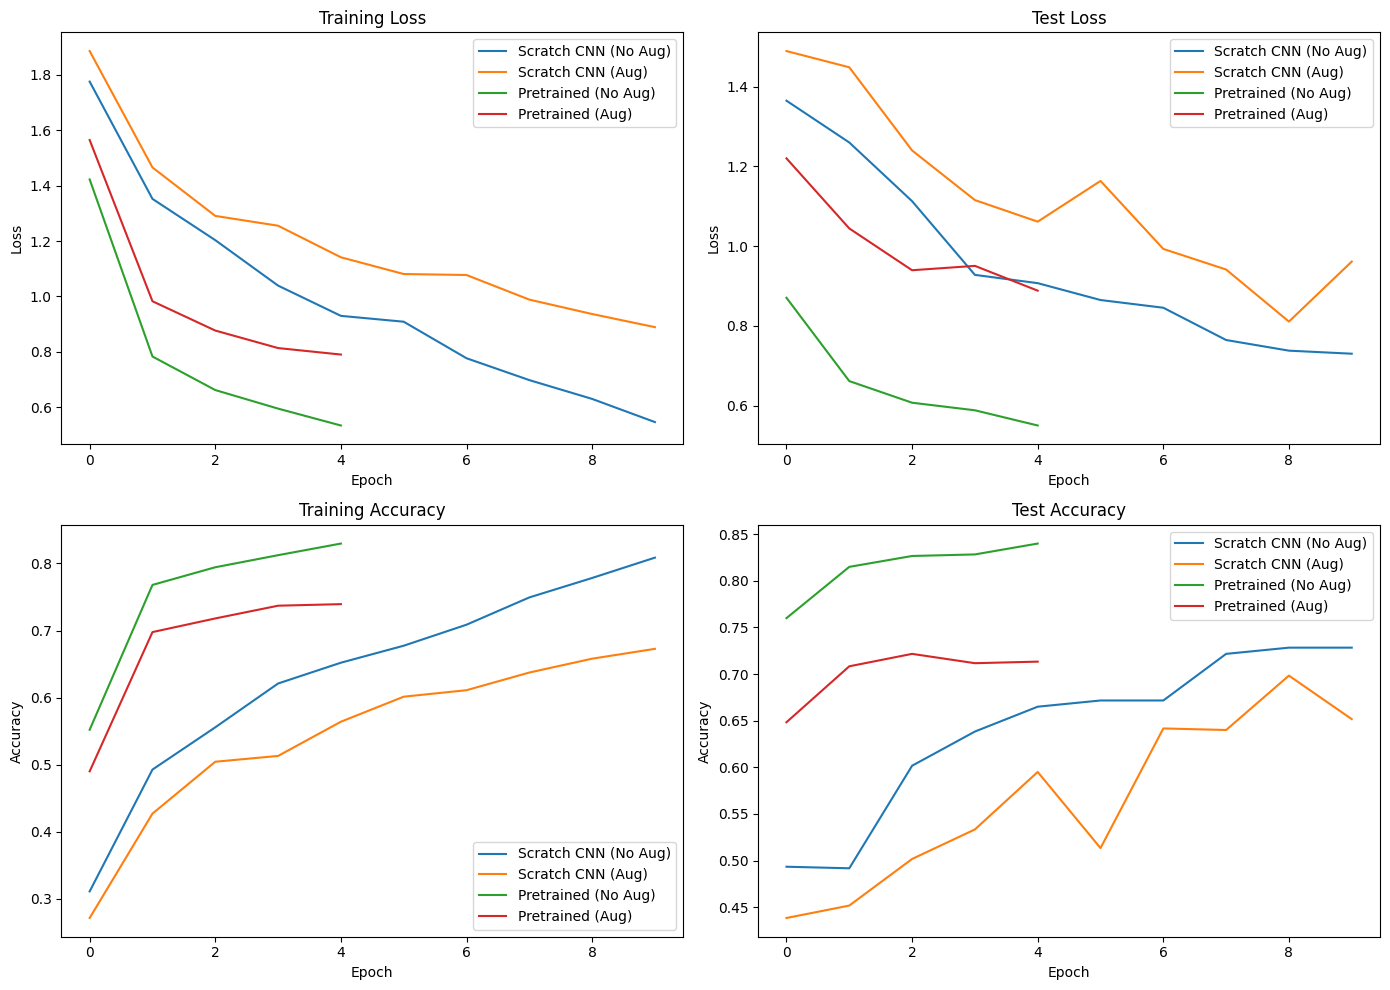

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

experiments = {
    "Scratch CNN (No Aug)": history_scratch_noaug,
    "Scratch CNN (Aug)": history_scratch_aug,
    "Pretrained (No Aug)": history_pretrained_noaug,
    "Pretrained (Aug)": history_pretrained_aug,
}

# Top-left: Training loss
for name, hist in experiments.items():
    axes[0, 0].plot(hist["train_loss"], label=name)
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Top-right: Test loss
for name, hist in experiments.items():
    axes[0, 1].plot(hist["test_loss"], label=name)
axes[0, 1].set_title("Test Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# Bottom-left: Training accuracy
for name, hist in experiments.items():
    axes[1, 0].plot(hist["train_acc"], label=name)
axes[1, 0].set_title("Training Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

# Bottom-right: Test accuracy
for name, hist in experiments.items():
    axes[1, 1].plot(hist["test_acc"], label=name)
axes[1, 1].set_title("Test Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("loss_accuracy_curves.png", dpi=150)
plt.show()

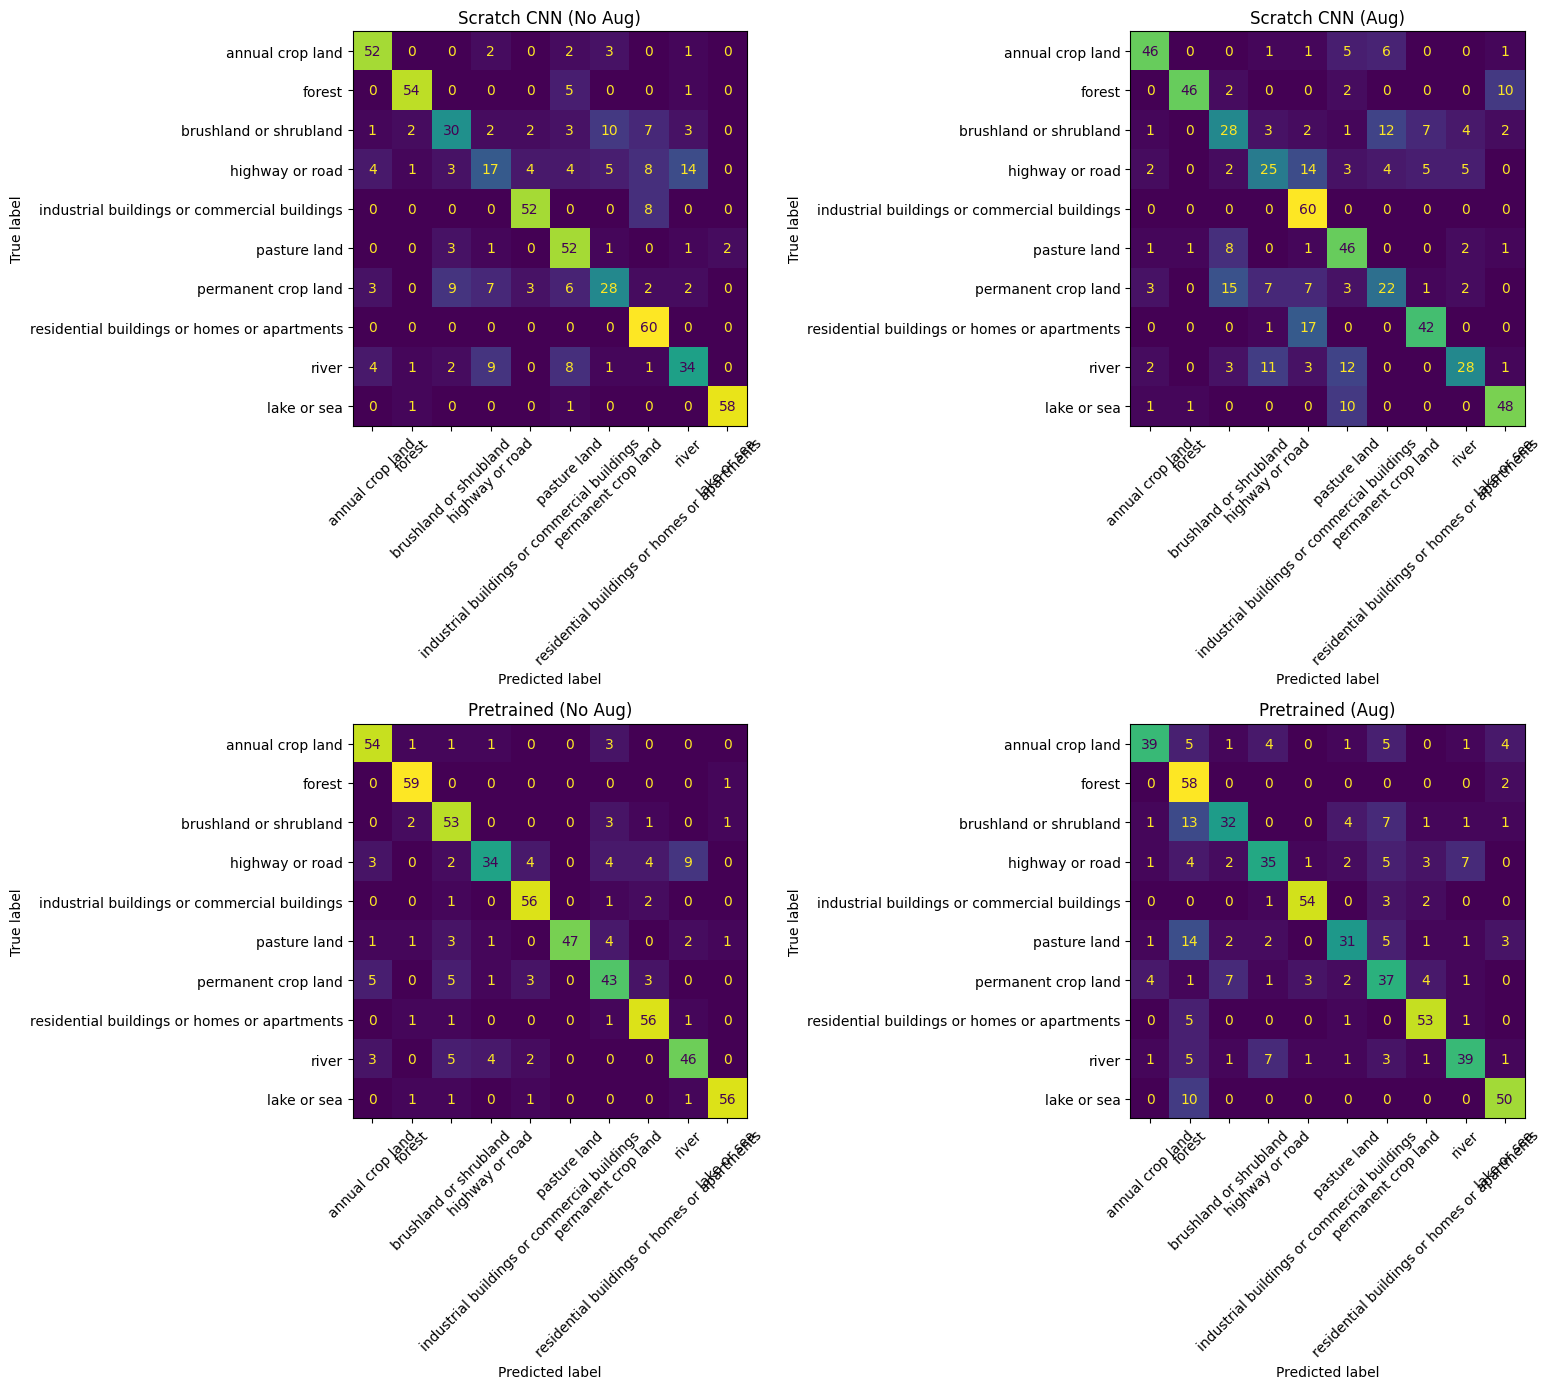

In [ ]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

models_dict = {
    "Scratch CNN (No Aug)": model_scratch_noaug,
    "Scratch CNN (Aug)": model_scratch_aug,
    "Pretrained (No Aug)": model_pretrained_noaug,
    "Pretrained (Aug)": model_pretrained_aug,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (name, mdl) in zip(axes.flat, models_dict.items()):
    labels, preds = get_predictions(mdl, test_loader)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()